# Prompt U-Net Version 312 Training

# Changes over v310

## 1. Architecture (`prompt_unet_312.py`)

- **No Mixed Precision (Float32)** — Disabled mixed precision training (pure `float32`). This provides a direct ablation against v310 to verify if mixed precision causes reduced speed on cpu inference.
- **No SE Attention** — Maintained from v310. Squeeze-and-Excitation channel gates are removed.
- **Pure Conv2D** — Maintained from v310. Every convolution is a standard `Conv2D`.

Filter schedule unchanged: `[48, 96, 192, 256, 384]`

---

## 2. DataGenerator changes (`DataGenerator.py`)

Uses exactly the same data generation as v310/311:
- **Scale Augmentation**: 50% literal 128×128 crops, 50% random quadratic crops bilinearly resized to 128×128.
- **Leakage Fix**: Origin computed exclusively from the Support/Prompt label (`total_label_r`).

## Setup

In [1]:
import os
import sys
import gc
import math as _m
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import mlflow
import tensorflow as tf

# v312: pure float32 — no mixed precision
# tf.keras.mixed_precision.set_global_policy("mixed_float16")

import logging
tf.get_logger().setLevel(logging.ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

print(f"TF  : {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

2026-04-19 14:52:31.220277: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776603151.242736      76 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776603151.250027      76 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776603151.267578      76 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776603151.267600      76 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776603151.267641      76 computation_placer.cc:177] computation placer alr

TF  : 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Allow importing from project root
notebook_dir = Path().resolve()
project_root  = notebook_dir.parent
sys.path.insert(0, str(project_root))

from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator  import DataGenerator

from utils.augmentations  import PromptUNetAugmenter
from utils.metrics        import dice_score_tf
from utils.visualization  import plot_result

from prompt_unet_312 import PromptUNet   # v312 architecture

## Data Loading

In [3]:
dataset_paths = [
    "data/train_data/nako_combined.npz",
    "data/train_data/total_seg_combined.npz",
    "data/train_data/msd_combined.npz",
]

dataloader    = DataLoader_npz(dataset_paths, val_size=0.01)
datagenerator = DataGenerator(dataloader)

print(f"Image size: {datagenerator.height} x {datagenerator.width}")


Loading NPZ dataset(s)…
Loaded 61 PIDs from /home/dpxuser/prompt-unet/data/train_data/nako_combined.npz
Loaded 45 PIDs from /home/dpxuser/prompt-unet/data/train_data/total_seg_combined.npz
Loaded 40 PIDs from /home/dpxuser/prompt-unet/data/train_data/msd_combined.npz

Final dataset size: 146 patients.

Image size: 128 x 128


## Hyperparameters

In [4]:
version           = "p_unet_312"

epochs            = 4000
batch_size        = 128
dp_training       = 3500
dp_testing        = 1000

offset            = 12
max_number_labels = 4

new_ds       = 50    # refresh training data every N epochs
new_val_loop = 300   # run validation every N epochs

# LR schedule phases (identical to v310)
warmup_epochs = 50
flat_epochs   = 1500

## Model & Optimizer

Same `WarmupFlatCosineDecay` schedule as v310:
- Phase 1 (50 ep): linear warmup 1e-6 → 1e-3  
- Phase 2 (1500 ep): flat plateau at 1e-3  
- Phase 3 (2450 ep): cosine decay 1e-3 → 1e-5

Optimizer: `Adam` (no `LossScaleOptimizer` because v312 is pure float32).

In [5]:
class WarmupFlatCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    """
    Three-phase LR schedule:
      1. Linear warmup  : initial_lr → peak_lr over warmup_steps gradient steps.
      2. Flat plateau   : stays at peak_lr for flat_steps gradient steps.
      3. Cosine decay   : peak_lr → min_lr over decay_steps gradient steps.
    """

    def __init__(self, warmup_steps, flat_steps, decay_steps,
                 initial_lr=1e-6, peak_lr=1e-3, alpha=0.01):
        super().__init__()
        self.warmup_steps = float(warmup_steps)
        self.flat_steps   = float(flat_steps)
        self.decay_steps  = float(decay_steps)
        self.initial_lr   = initial_lr
        self.peak_lr      = peak_lr
        self.min_lr       = alpha * peak_lr

    def __call__(self, step):
        step     = tf.cast(step, tf.float32)
        flat_end = self.warmup_steps + self.flat_steps

        # Phase 1: linear warmup
        warmup_frac = tf.minimum(step / self.warmup_steps, 1.0)
        warmup_lr   = self.initial_lr + (self.peak_lr - self.initial_lr) * warmup_frac

        # Phase 3: cosine decay
        decay_step = step - flat_end
        decay_frac = tf.minimum(tf.maximum(decay_step / self.decay_steps, 0.0), 1.0)
        cosine_lr  = self.min_lr + 0.5 * (self.peak_lr - self.min_lr) * (
                         1.0 + tf.cos(_m.pi * decay_frac))

        return tf.where(step < self.warmup_steps, warmup_lr,
               tf.where(step < flat_end,          self.peak_lr, cosine_lr))

    def get_config(self):
        return {
            "warmup_steps": self.warmup_steps, "flat_steps": self.flat_steps,
            "decay_steps":  self.decay_steps,  "initial_lr":  self.initial_lr,
            "peak_lr":      self.peak_lr,       "min_lr":      self.min_lr,
        }


# ── Build model ───────────────────────────────────────────────────────────────
model = PromptUNet(height=datagenerator.height, width=datagenerator.width)

# Warm-up forward pass to fully initialise all layers
_dummy_x = tf.random.uniform([1, datagenerator.height, datagenerator.width, 1])
_dummy_p = tf.random.uniform([1, datagenerator.height, datagenerator.width, 2])
_ = model.this([_dummy_x, _dummy_p])

print(f"Trainable params: {model.this.count_params():,}")

# ── Build optimizer (plain Adam, no LossScaleOptimizer) ───────────────────────
steps_per_epoch   = dp_training // batch_size

lr_schedule = WarmupFlatCosineDecay(
    warmup_steps = warmup_epochs * steps_per_epoch,
    flat_steps   = flat_epochs   * steps_per_epoch,
    decay_steps  = (epochs - warmup_epochs - flat_epochs) * steps_per_epoch,
    initial_lr   = 1e-6,
    peak_lr      = 1e-3,
    alpha         = 0.01,
)

model.optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

I0000 00:00:1776603640.788615      76 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46640 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1776603649.121842      76 cuda_dnn.cc:529] Loaded cuDNN version 91002


Trainable params: 27,905,729


## Augmentation Pipeline

Same probabilities as v310.

In [6]:
augmenter = PromptUNetAugmenter(
    prob_photo             = 0.45,
    prob_gamma             = 0.35,
    prob_noise             = 0.40,
    prob_independent_noise = 0.50,
    prob_geometric         = 0.50,
    prob_morph             = 0.30,
    prob_dropout           = 0.40,
    prob_false_pos         = 0.60,
    gamma_range                 = (0.85, 1.25),
    noise_std_range             = (0.0, 0.10),
    independent_noise_std_range = (0.0, 0.01),
)

## Persistent tf.data Pipeline

The pipeline graph (including `.map(augmenter)`) is built **once** here.  
When fresh training data is needed, only the numpy buffer is swapped — no TF graph nodes accumulate over time.

In [7]:
# ── Shared numpy buffer ───────────────────────────────────────────────────────
_buf = {"x": None, "y": None, "p": None, "m": None}

def refresh_train_data():
    """Pull fresh random training data into the numpy buffer."""
    x_np, y_np, p_np, m_np, _ = datagenerator.get_data_points_numpy(
        max_data_points   = dp_training,
        offset            = offset,
        max_number_labels = max_number_labels,
    )
    _buf["x"] = x_np
    _buf["y"] = y_np
    _buf["p"] = p_np
    _buf["m"] = m_np
    gc.collect()


def _data_gen():
    """Yields one shuffled sample at a time from the numpy buffer."""
    n       = len(_buf["x"])
    indices = np.random.permutation(n)
    for i in indices:
        yield _buf["x"][i], _buf["y"][i], _buf["p"][i], _buf["m"][i]


H, W = datagenerator.height, datagenerator.width

# Build the pipeline graph ONCE for the entire training run
train_ds = (
    tf.data.Dataset.from_generator(
        _data_gen,
        output_signature=(
            tf.TensorSpec(shape=(H, W, 1), dtype=tf.float32),  # image
            tf.TensorSpec(shape=(H, W, 1), dtype=tf.float32),  # label
            tf.TensorSpec(shape=(H, W, 2), dtype=tf.float32),  # prompt
            tf.TensorSpec(shape=(),        dtype=tf.float32),  # modality
        )
    )
    .map(augmenter, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

print("Pipeline ready.")

Pipeline ready.


## Training

2026/04/19 15:01:01 INFO mlflow.tracking.fluent: Experiment with name 'p_unet_312' does not exist. Creating a new experiment.


Creating new Data Points ...
It took 6 seconds
Creating new Data Points ...
It took 163 seconds


E0000 00:00:1776603855.463402      76 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-04-19 15:04:49.929736: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch    1  loss: 0.750922


2026-04-19 15:05:10.565762: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

2026-04-19 15:10:05.198338: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch   16  loss: 0.170680
Epoch   17  loss: 0.166839
Epoch   18  loss: 0.156725
Epoch   19  loss: 0.147644
Epoch   20  loss: 0.146956
Epoch   21  loss: 0.141143
Epoch   22  loss: 0.135124
Epoch   23  loss: 0.135854
Epoch   24  loss: 0.128060
Epoch   25  loss: 0.124227
Epoch   26  loss: 0.124789
Epoch   27  loss: 0.117768
Epoch   28  loss: 0.118948
Epoch   29  loss: 0.116172
Epoch   30  loss: 0.112195
Epoch   31  loss: 0.122241


2026-04-19 15:15:28.277951: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch   32  loss: 0.117447
Epoch   33  loss: 0.125463
Epoch   34  loss: 0.120558
Epoch   35  loss: 0.121461
Epoch   36  loss: 0.132579
Epoch   37  loss: 0.115314
Epoch   38  loss: 0.112935
Epoch   39  loss: 0.117256
Epoch   40  loss: 0.110935
Epoch   41  loss: 0.108285
Epoch   42  loss: 0.105139
Epoch   43  loss: 0.107596
Epoch   44  loss: 0.103998
Epoch   45  loss: 0.100482
Epoch   46  loss: 0.098559
Epoch   47  loss: 0.099361
Epoch   48  loss: 0.096898
Epoch   49  loss: 0.097602
Epoch   50  loss: 0.097261


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.492968..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.570171..5.0].


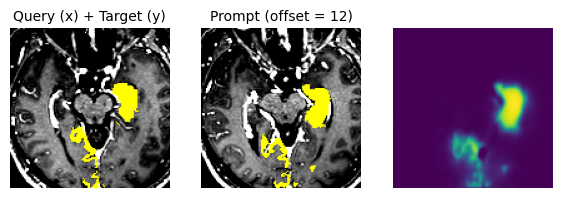

Creating new Data Points ...
It took 116 seconds
Epoch   51  loss: 0.076038
Epoch   52  loss: 0.080170
Epoch   53  loss: 0.080838
Epoch   54  loss: 0.080064
Epoch   55  loss: 0.075228
Epoch   56  loss: 0.071189
Epoch   57  loss: 0.070152
Epoch   58  loss: 0.070435
Epoch   59  loss: 0.070468
Epoch   60  loss: 0.069664
Epoch   61  loss: 0.069652
Epoch   62  loss: 0.071569
Epoch   63  loss: 0.069006


2026-04-19 15:28:13.761603: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch   64  loss: 0.067508
Epoch   65  loss: 0.066233
Epoch   66  loss: 0.067049
Epoch   67  loss: 0.065760
Epoch   68  loss: 0.064547
Epoch   69  loss: 0.065027
Epoch   70  loss: 0.065140
Epoch   71  loss: 0.065676
Epoch   72  loss: 0.064096
Epoch   73  loss: 0.068777
Epoch   74  loss: 0.066173
Epoch   75  loss: 0.064376
Epoch   76  loss: 0.063276
Epoch   77  loss: 0.064081
Epoch   78  loss: 0.062900
Epoch   79  loss: 0.063639
Epoch   80  loss: 0.063940
Epoch   81  loss: 0.062477
Epoch   82  loss: 0.061727
Epoch   83  loss: 0.060928
Epoch   84  loss: 0.061650
Epoch   85  loss: 0.061325
Epoch   86  loss: 0.061078
Epoch   87  loss: 0.060826
Epoch   88  loss: 0.060500
Epoch   89  loss: 0.060283
Epoch   90  loss: 0.060563
Epoch   91  loss: 0.065297
Epoch   92  loss: 0.066254
Epoch   93  loss: 0.063007
Epoch   94  loss: 0.061900
Epoch   95  loss: 0.062002
Epoch   96  loss: 0.060013
Epoch   97  loss: 0.060862
Epoch   98  loss: 0.060557
Epoch   99  loss: 0.059756
Epoch  100  loss: 0.059543


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.492968..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.570171..5.0].


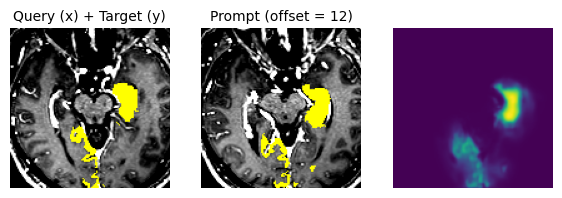

Creating new Data Points ...
It took 88 seconds
Epoch  101  loss: 0.081479
Epoch  102  loss: 0.077780
Epoch  103  loss: 0.078538
Epoch  104  loss: 0.078711
Epoch  105  loss: 0.074429
Epoch  106  loss: 0.074277
Epoch  107  loss: 0.074173
Epoch  108  loss: 0.074179
Epoch  109  loss: 0.074703
Epoch  110  loss: 0.074308
Epoch  111  loss: 0.074849
Epoch  112  loss: 0.076340
Epoch  113  loss: 0.073893
Epoch  114  loss: 0.074320
Epoch  115  loss: 0.071980
Epoch  116  loss: 0.074618
Epoch  117  loss: 0.073054
Epoch  118  loss: 0.072301
Epoch  119  loss: 0.070183
Epoch  120  loss: 0.071699
Epoch  121  loss: 0.074537
Epoch  122  loss: 0.070478
Epoch  123  loss: 0.069139
Epoch  124  loss: 0.069821
Epoch  125  loss: 0.070563
Epoch  126  loss: 0.074406
Epoch  127  loss: 0.070858


2026-04-19 15:51:16.718410: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch  128  loss: 0.068337
Epoch  129  loss: 0.068984
Epoch  130  loss: 0.069751
Epoch  131  loss: 0.069585
Epoch  132  loss: 0.070650
Epoch  133  loss: 0.069162
Epoch  134  loss: 0.069546
Epoch  135  loss: 0.070322
Epoch  136  loss: 0.081323
Epoch  137  loss: 0.074616
Epoch  138  loss: 0.071944
Epoch  139  loss: 0.073827
Epoch  140  loss: 0.070161
Epoch  141  loss: 0.070772
Epoch  142  loss: 0.070610
Epoch  143  loss: 0.072572
Epoch  144  loss: 0.070590
Epoch  145  loss: 0.068438
Epoch  146  loss: 0.069676
Epoch  147  loss: 0.070661


In [ ]:
def fit(epochs):
    mlflow.set_experiment(version)

    with mlflow.start_run():

        mlflow.log_params({
            "batch_size"        : batch_size,
            "max_number_labels" : max_number_labels,
            "num_epochs"        : epochs,
            "dp_training"       : dp_training,
            "offset"            : offset,
            "loss_function"     : "binary_crossentropy",
            "warmup_epochs"     : warmup_epochs,
            "flat_epochs"       : flat_epochs,
            "prob_geometric"    : augmenter.prob_geometric,
            "prob_morph"        : augmenter.prob_morph,
            "gamma_range"       : str(augmenter.gamma_range),
            "trainable_params"  : model.this.count_params(),
            "scale_augmentation": "50% crop 128px / 50% crop [128,256]px resized",
            "leakage_fix"       : "crop origin from support label only",
            "se_attention"      : "disabled",
            "mixed_precision"   : "false",
        })

        # ── Validation dataset (built once, no augmentation) ───────────────────
        val_x, val_y, val_p, val_m, _ = datagenerator.get_val_data_points_numpy(
            max_data_points   = dp_testing,
            offset            = offset,
            max_number_labels = max_number_labels,
        )
        test_ds = (
            tf.data.Dataset.from_tensor_slices((val_x, val_y, val_p, val_m))
            .batch(1)
        )

        # ── Prime the training buffer before the loop ──────────────────────────
        refresh_train_data()

        for epoch in range(epochs):

            model.train_loss.reset_state()

            # Log learning rate
            lr = model.optimizer.learning_rate
            if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
                lr = float(lr(epoch * steps_per_epoch))
            else:
                lr = float(lr.numpy())
            mlflow.log_metric("learning_rate", lr, step=epoch)

            # Checkpoint every 8 epochs
            if epoch % 8 == 0 and epoch != 0:
                model.this.save(f"{version}.keras")

            # Validation every new_val_loop epochs
            if epoch % new_val_loop == 0 and epoch != 0:
                total_dice = 0.0
                for z in test_ds:
                    pred = model.this([z[0], z[2]], training=False)
                    total_dice += float(dice_score_tf(z[1][..., 0:1], pred))
                val_loss = 1.0 - total_dice / dp_testing
                mlflow.log_metric("validation_loss", val_loss, step=epoch)
                print(f"  Validation loss: {val_loss:.4f}")

            # Refresh training data every new_ds epochs
            if epoch % new_ds == 0 and epoch != 0:
                # Visualise one validation prediction
                z_test = next(iter(test_ds))
                pred   = model.this([z_test[0], z_test[2]], training=False)
                plot_result(z_test[0][0], z_test[1][0], z_test[2][0], pred[0], offset, "")

                # Swap numpy buffer — pipeline graph stays intact
                refresh_train_data()

            # Train one epoch
            model.train_epoch(train_dataset=train_ds)

            epoch_loss = float(model.train_loss.result())
            print(f"Epoch {epoch + 1:>4d}  loss: {epoch_loss:.6f}")
            mlflow.log_metric("train_loss", epoch_loss, step=epoch)


fit(epochs)